In [74]:
import os
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages,MessagesState
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
import json
import urllib.request
import urllib.parse
from langchain_core.tools import tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.utilities import ArxivAPIWrapper
from IPython.display import display,Image

In [75]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")

In [76]:
# --- 1. Real Wikipedia Tool ---
# Built-in LangChain tool that natively searches Wikipedia
wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=1000))


# --- 2. Real ArXiv Research Tool ---
@tool
def search_arxiv(query: str) -> str:
    """Search the ArXiv academic database for scientific papers, math, and AI research."""
    arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=1500)
    return arxiv.run(query)

@tool
def get_live_weather(city: str) -> str:
    """Fetch real-time weather data for a specific city name."""
    # Step 1: Convert city name to URL-safe format (e.g., "New York" -> "New%20York")
    encoded_city = urllib.parse.quote(city)
    
    # Open-Meteo's free geocoding API to get latitude/longitude
    geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={encoded_city}&count=1&language=en&format=json"
    
    try:
        # Fetch coordinates
        with urllib.request.urlopen(geo_url) as geo_response:
            geo_data = json.loads(geo_response.read().decode())
            
            if not geo_data.get("results"):
                return f"Could not find coordinates for city: {city}"
                
            location = geo_data["results"][0]
            latitude = location["latitude"]
            longitude = location["longitude"]
            resolved_city_name = location["name"]
            
        # Step 2: Fetch the weather using the retrieved coordinates
        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
        
        with urllib.request.urlopen(weather_url) as weather_response:
            weather_data = json.loads(weather_response.read().decode())
            current = weather_data['current_weather']
            return f"The current temperature in {resolved_city_name} is {current['temperature']}°C with a wind speed of {current['windspeed']} km/h."
            
    except Exception as e:
        return f"Error fetching weather data: {str(e)}"




tools=[wikipedia_tool,search_arxiv,get_live_weather]




In [77]:
t_llm=llm.bind_tools(tools)

In [78]:
def botnode(state:MessagesState):
    response=t_llm.invoke(state["messages"])
    return {"messages":[response]}


tool_node=ToolNode(tools)    

In [79]:
workflow=StateGraph(MessagesState)

In [80]:
workflow.add_node("bot_node",botnode)
workflow.add_node("tools",tool_node)

In [81]:
workflow.add_edge(START,"bot_node")
workflow.add_conditional_edges(
"bot_node",tools_condition
)
workflow.add_edge("tools","bot_node")



In [82]:
Memory=MemorySaver()
app=workflow.compile(checkpointer=Memory)

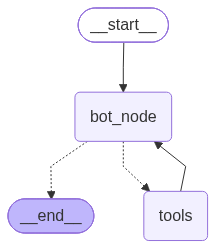

In [83]:
display(Image(app.get_graph().draw_mermaid_png()))

In [84]:
config={"configurable":{"thread_id":"session-1"}}

In [85]:
resp=app.invoke({"messages":[("user","hello am abbas how are u")]},config=config)




In [86]:
resp["messages"][-1].pretty_print()


================================== Ai Message ==================================

Hello Abbas! I’m doing great, thanks for asking. How can I help you today?


In [87]:
resp

{'messages': [HumanMessage(content='hello am abbas how are u', additional_kwargs={}, response_metadata={}, id='8deee7c1-fc9d-4b43-a8c4-b03c5ecea83b'),
  AIMessage(content='Hello Abbas! I’m doing great, thanks for asking. How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hello am abbas how are u". It\'s a greeting. We should respond politely, ask how they are, maybe ask if they need assistance. No need for tools.'}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 223, 'total_tokens': 290, 'completion_time': 0.140564324, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.011220481, 'prompt_tokens_details': None, 'queue_time': 0.302781082, 'total_time': 0.151784805}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_f640395b96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a03df9-34e7-79b0-90e9-58fd60d5db23-0', tool_calls=[], 

In [88]:
resp=app.invoke({"messages":[("user","who am i ")]},config=config)
resp["messages"][-1].pretty_print()

================================== Ai Message ==================================

You’ve told me your name is **Abbas**. Beyond that, I don’t have any additional details about you—so feel free to share anything you’d like me to know (your interests, what you’re working on, or how I can help), and I’ll do my best to assist!


In [89]:
config={"configurable":{"thread_id":"session-2"}}
resp=app.invoke({"messages":[("what is the weather of the bosan city call the tool")]},config=config)
resp["messages"][-1].pretty_print()

================================== Ai Message ==================================

The current weather in **Bosan** (Boşan) is:

- **Temperature:** ≈ 25.8 °C  
- **Wind speed:** ≈ 39.5 km/h  

Let me know if you’d like more details (e.g., humidity, forecast, or weather for a different location).


In [90]:
resp

{'messages': [HumanMessage(content='what is the weather of the bosan city call the tool', additional_kwargs={}, response_metadata={}, id='e88484d7-a1a5-4d39-b7f8-da6d3b18cbe7'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants weather of "the bosan city". Likely a city named Bosan? Might be "Bosan" in Pakistan? Let\'s search.', 'tool_calls': [{'id': 'fc_9c72bffc-5dd3-4e99-95f4-f910b9c1ec22', 'function': {'arguments': '{"city":"Bosan"}', 'name': 'get_live_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 228, 'total_tokens': 288, 'completion_time': 0.124747451, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.016146546, 'prompt_tokens_details': None, 'queue_time': 0.292866266, 'total_time': 0.140893997}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_96d96a151c', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'gro

In [91]:

resp=app.invoke({"messages":[("what is the weather of the dir lower city ")]},config=config)
resp["messages"][-1].pretty_print()

================================== Ai Message ==================================

Here’s the latest weather information for **Dir (Pakistan)** – the nearest location the service could locate for the “Lower Dir” area:

- **Temperature:** ≈ 29 °C  
- **Wind speed:** ≈ 4.2 km/h  

*Note:* The live‑weather service doesn’t have a separate entry specifically named “Lower Dir,” so the data shown is for the broader Dir region in Khyber Pakhtunkhwa, Pakistan. If you need a more precise forecast (e.g., for a particular town or a longer outlook), let me know and I can look up a nearby city or provide a general forecast for the district.
